In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [3]:
# Load the dataset
df = pd.read_csv(r"C:\Users\USER\Desktop\Basic codes in the WQU\HAR heart disease project\heart.csv")

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [7]:
df.shape

(303, 14)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

In [11]:
df = df.dropna()

In [12]:
# convert target to binary: 0 = no disease, 1 = has the disease
df['label'] = (df['num'] > 0).astype(int)

In [20]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,label
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0,0


In [16]:
# select two features for plotting and modeling the perceptron. 
X_real = df[['thalach', 'oldpeak']].values
y_real = df['label'].values


print("X_real shape:", X_real.shape)
print("y_real class distribution:", np.bincount(y_real))

X_real shape: (297, 2)
y_real class distribution: [160 137]


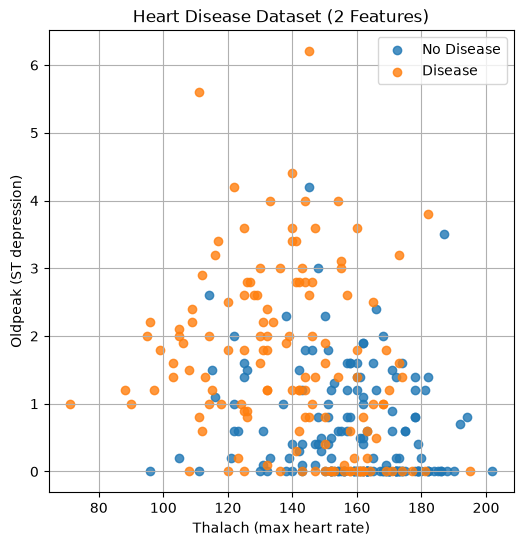

In [17]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,6))
plt.scatter(X_real[y_real==0,0], X_real[y_real==0, 1], label='No Disease', alpha=0.8)
plt.scatter(X_real[y_real==1, 0], X_real[y_real==1, 1], label='Disease', alpha=0.8)

plt.xlabel("Thalach (max heart rate)")
plt.ylabel("Oldpeak (ST depression)")
plt.title("Heart Disease Dataset (2 Features)")
plt.legend()
plt.grid(True)
plt.show()

The dataset is increbily messy and a perceptron would be important in helping to separate into two classes -- [disease] and [no disease]

In [18]:
w_real = np.random.randn(X_real.shape[1])   # shape (2,)
b_real = np.random.randn()


# Training settings
lr = 0.1
epochs = 50
errors_real = []


# step function
def step(z):
    return 1 if z >= 0 else 0


# Training loop
for epoch in range(epochs):
    total_errors = 0
    for xi, yi in zip(X_real, y_real):
        z = np.dot(w_real, xi) + b_real
        y_hat = step(z)


        error = yi - y_hat
        if error != 0:
            w_real += lr * error * xi
            b_real += lr * error
            total_errors += 1

    errors_real.append(total_errors)


print("Final weights:", w_real)
print("Final bias:", b_real)

Final weights: [  2.39652463 236.46135106]
Final bias: 38.017791602085715


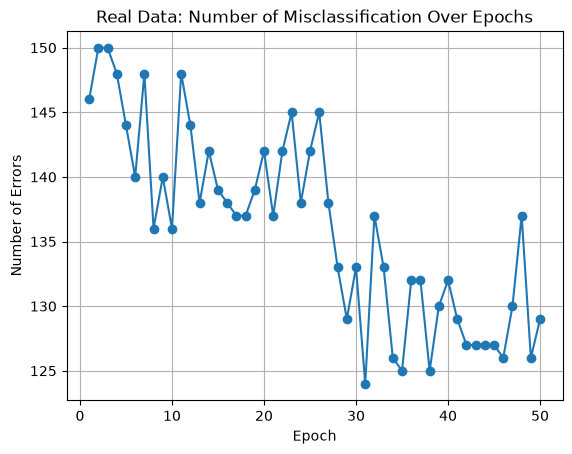

In [19]:
#  Plot the training errors
plt.plot(range(1, epochs+1), errors_real, marker='o')
plt.title('Real Data: Number of Misclassification Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Number of Errors')
plt.grid(True)
plt.show()

This goes to demonstrate that the data in the real world is messy and perceptrons do not do a good job in classifying them